In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
from scipy import stats

plt.rcParams["figure.figsize"] = (15,10)

# Part 1
### Integrating the standard normal distribution and checking Z-score for 1,2,3 sigma

### Checking sigma values for 1,2,3 sigma match Z-scores

In [2]:
print(round(stats.norm.ppf(0.15866)))

-1


In [3]:
print(round(stats.norm.ppf(0.02275)))

-2


In [4]:
print(round(stats.norm.ppf(0.00135)))

-3


### The Z-scores for the sigma values do match up. They are negative because the the inputs were taken from the complementary cumulative Z table which correspond to the area of the distribution above Z.

# Part 2

### Generating a chi-squared distribution with 100,000 samples, with a mean value of 0, a scale of 1, and 3 degrees of freedom

### Plotting the distribution and histogram with 100 bins

In [5]:
chi2_distribution = stats.chi2.rvs(3, loc = 0, scale = 1, size = 100000)

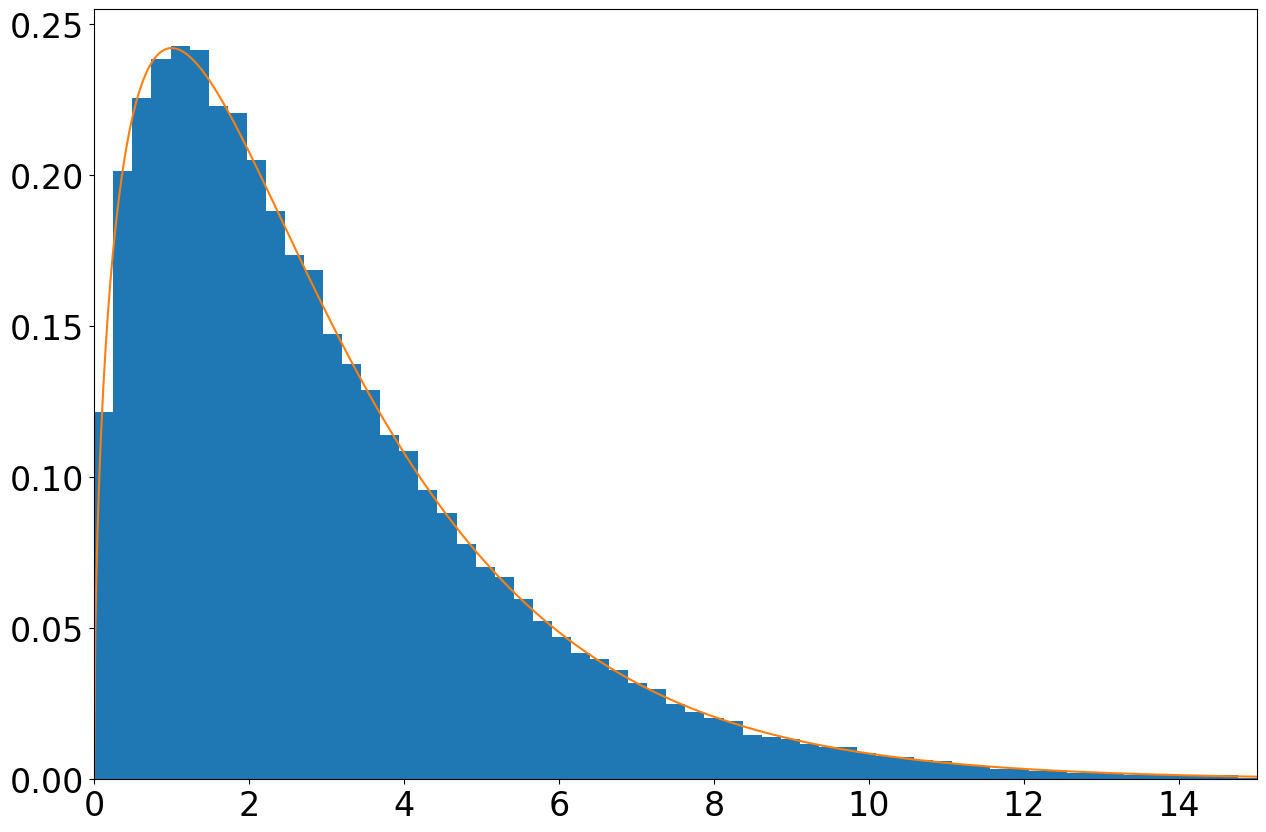

In [6]:
fig, ax = plt.subplots(1, 1)
ax.hist(chi2_distribution, 100, density=True)
plt.tick_params(labelsize = 24)
plt.xlim([0, 15])
x = np.linspace(0, 15, 1000)
ax.plot(x, stats.chi2.pdf(x, 3, loc=0, scale=1))
plt.show()

# Part 3

### A) The hypothetical value being measured is the luminosity of a star

### B) The statistical question we want to ask is: What is the probability of a star being randomly picked from the sample having a luminosity of 6 or lower.

### C) The Chi Squared probability distribution is represented by:

$$ f\left(x,k\right)\ =\ \frac{1}{2^{\frac{k}{2}}\ \Gamma\left(\frac{k}{2}\right)}x^{-\frac{k}{2-1}}e^{\left(-\frac{x}{2}\right)} $$

To find the probability of a the star having a luminosity of 6 or lower from this sample, you would integrate over the probability distribution function from negative infinity to 6:

$$ \int_{-\infty}^{6}f\left(x,k\right)\ =\ \frac{1}{2^{\frac{k}{2}}\ \Gamma\left(\frac{k}{2}\right)}x^{-\frac{k}{2-1}}e^{\left(-\frac{x}{2}\right)} $$

### D) Using stats.chi2.cdf() to integrate over the chi squared probability distribution function. The result is there is around 0.89 probability of a randomly selected star having a luminosity of 6 or lower

In [7]:
stats.chi2.cdf(6, 3, loc = 0, scale = 1)

np.float64(0.8883897749052874)

### E) Converting the probability to the equivalent sigma using stats.norm.ppf(). The result shows that the sigma of this value is around 1.22

In [8]:
print(stats.norm.ppf(0.8883897749052874))

1.2180092696511942


# Part 4

### Checking the sigma and probabilities of finding a luminosity of 3 or lower. This shows that there is a 0.608 probability and corresponding sigma value of 0.275

In [9]:
stats.chi2.cdf(3, 3, loc = 0, scale = 1)

np.float64(0.6083748237289109)

In [10]:
print(stats.norm.ppf(0.6083748237289109))

0.27508575874430374


### Checking the sigma and probabilities of finding a luminosity of 8 or lower. This shows that there is a 0.954 probability and corresponding sigma value of 1.68

In [11]:
stats.chi2.cdf(8, 3, loc = 0, scale = 1)

np.float64(0.9539882943107686)

In [12]:
print(stats.norm.ppf(0.9539882943107686))

1.6848194488034423


### These results are consistent with what we'd expect. As you change the hypothetical result to be more likely (higher luminosity), the associated probability and sigma increases, indicating more statistical confidence.